In [1]:
%load_ext autoreload
%autoreload 2
import os


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm.notebook import tqdm

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules')

from spikeparam.patch.fit import Spike, SpikeGroup
from spikeparam_plotting import plot_corr_heatmap_only_spk, display_feature_table

sns.set_style("whitegrid", {'axes.grid': False})

In [3]:
# ── Run-control flags ─────────────────────────────────────────────────────────
FORCE_RERUN  = False   # set True to recompute and overwrite pickles
figure_style = True    # set False for plain exploratory style

In [4]:
def apply_figure_style(ax, xlabel='Time (ms)', ylabel='Voltage (mV)',
                       xticks=None, yticks=None, legend_fontsize=18,
                       linewidth=3, point_size=None):
    plt.rcParams['font.family'] = 'Helvetica Neue'

    fig = ax.get_figure()
    fig.set_size_inches(8, 4)

    for line in ax.get_lines():
        line.set_linewidth(linewidth)
        if point_size is not None and line.get_marker() not in ('None', None, ''):
            line.set_markersize(point_size)

    if point_size is not None:
        for coll in ax.collections:
            coll.set_sizes([point_size ** 2])

    ax.set_xlabel(xlabel, fontsize=26, fontweight='bold', fontfamily='Helvetica Neue')
    ax.set_ylabel(ylabel, fontsize=26, fontweight='bold', fontfamily='Helvetica Neue')

    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.tick_params(axis='both', which='major', labelsize=22, width=2.5, color='black')

    fig.canvas.draw()
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Helvetica Neue')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(2.5)
        ax.spines[spine].set_color('black')

    legend = ax.get_legend()
    if legend:
        _handles = legend.legend_handles
        _labels  = [t.get_text() for t in legend.get_texts()]
        legend.remove()
        legend = ax.legend(_handles, _labels,
                           loc='center left', bbox_to_anchor=(1.01, 0.5),
                           frameon=False)
        plt.setp(legend.get_texts(), fontsize=legend_fontsize,
                 fontweight='bold', fontfamily='Helvetica Neue')
        for handle in legend.legend_handles:
            handle.set_markersize(legend_fontsize * 0.75)

### Part 1: ALL-OR-NONE + CODES BACKGROUND

In [5]:
patch_c14 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c14patch_filt.npy'
patch_fs_c14 = 50023.8986874656
#get patch data 
patch_filt_c14 = np.load(patch_c14)
patch_c14_one_ms = float(patch_fs_c14  / 1000)
patch_times_c14 = np.arange(0, np.shape(patch_filt_c14 )[0]) / patch_c14_one_ms # in ms instead of sec

In [6]:
#flip sign of patch filt
patch_filt_c14 = -patch_filt_c14

#### Example "raw" spike data - sp1-rh c14

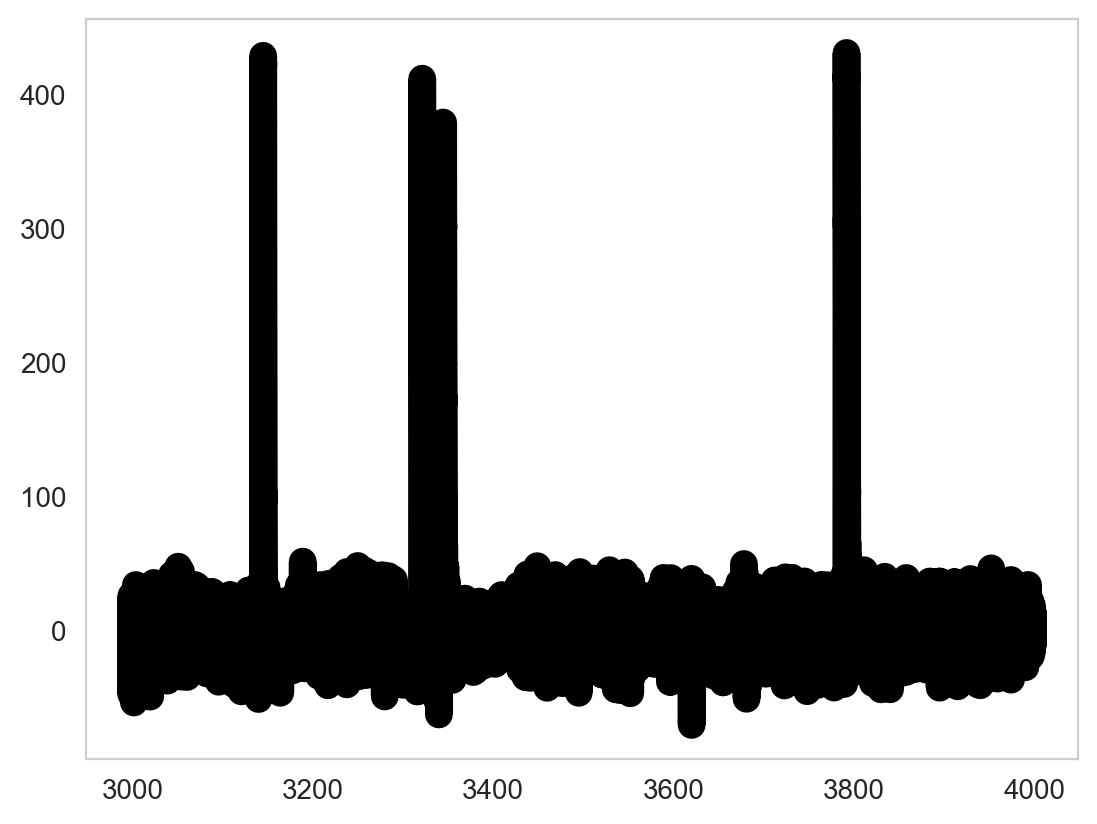

In [7]:
plt.plot(patch_times_c14[150000:200000], patch_filt_c14[150000:200000], color = 'k', linewidth=10)

#### Binarized version 

In [8]:
# Define a threshold, e.g., everything above 100 becomes 1, everything else 0
threshold = 100
binarized_data = np.where(patch_filt_c14[150000:200000] > threshold, 1, 0)
all_binarized_data = np.where(patch_filt_c14 > threshold, 1, 0)

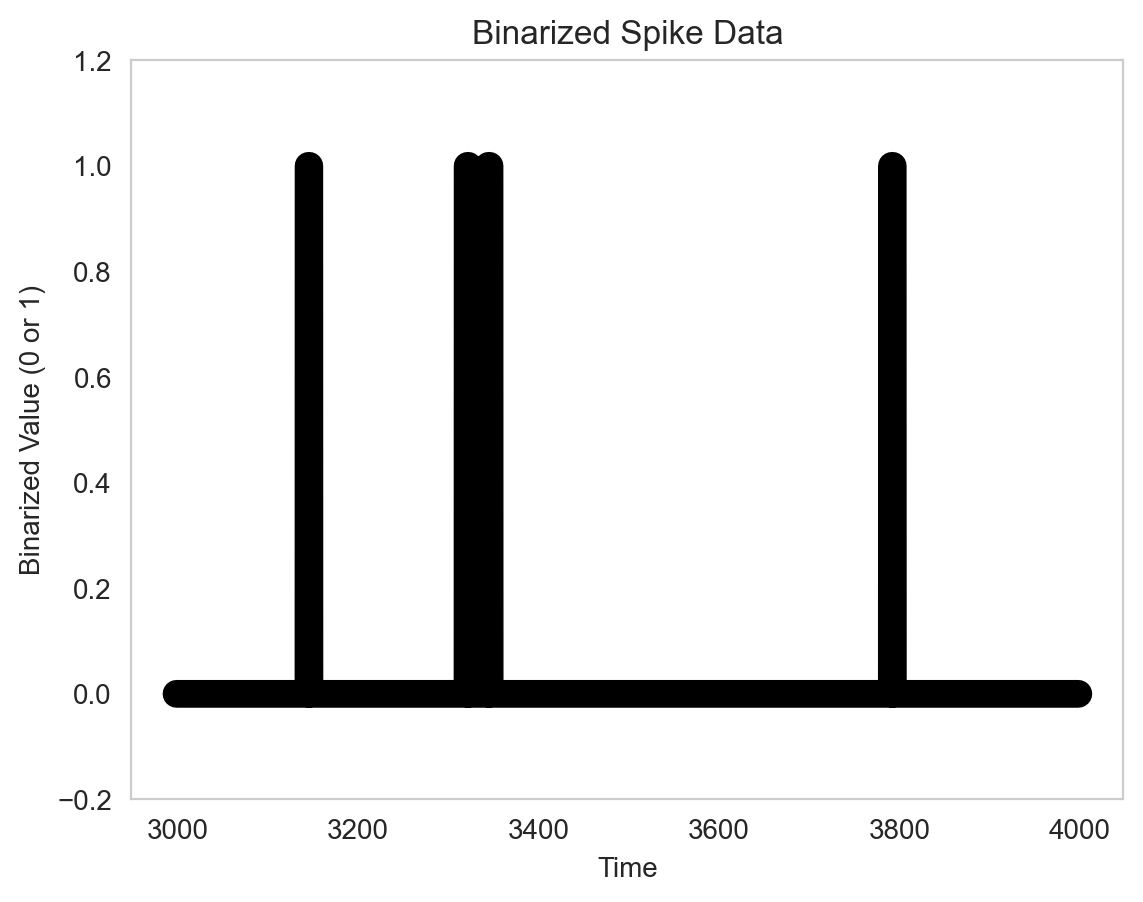

In [9]:
# Plot the binarized data

plt.plot(patch_times_c14[150000:200000], binarized_data, color='black', linewidth=10)
plt.title('Binarized Spike Data')
plt.xlabel('Time')
plt.ylabel('Binarized Value (0 or 1)')
plt.ylim(-0.2, 1.2)  # Keep the y-axis limits between -0.2 and 1.2 for clarity

plt.show()

#### Rate code figure 

In [10]:
# Define your bin size (in time units, e.g., ms)
bin_size = 150000 # For example, 50 ms bins

# Calculate the number of bins
num_bins = int(np.ceil(len(patch_times_c14) / bin_size))


In [11]:
# Initialize an array to hold the PSTH data
psth = np.zeros(num_bins)

# Loop over each bin and sum the spikes
for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = min((i + 1) * bin_size, len(all_binarized_data))
    psth[i] = np.sum(all_binarized_data[start_idx:end_idx])

# Convert spike counts to rate by dividing by bin size
psth_rate = psth / (bin_size * (1e-3))  # Convert to spikes per second (Hz)

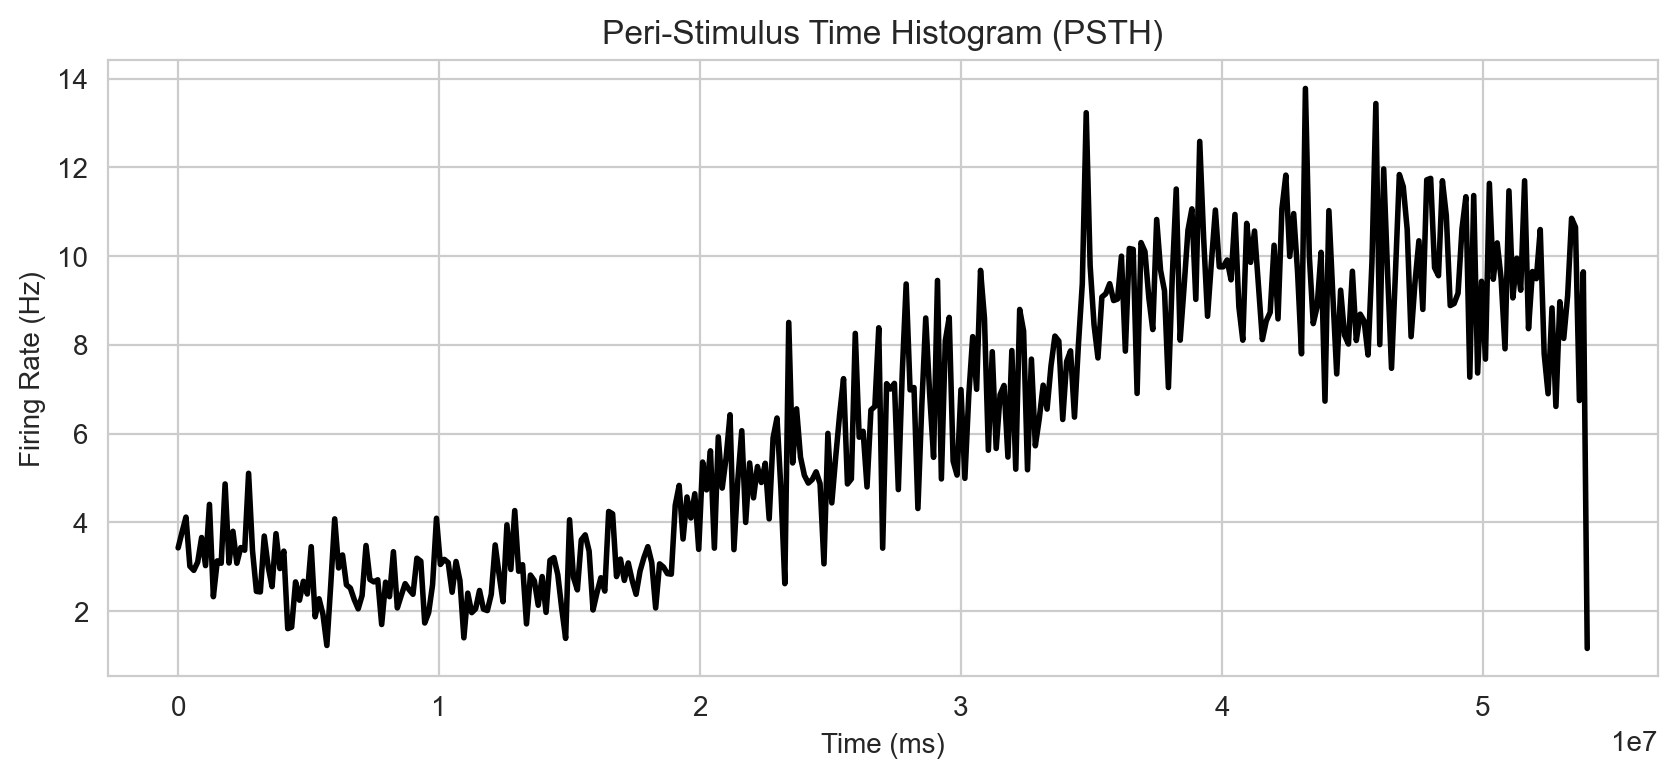

In [12]:
# Generate time points for the PSTH plot
psth_time = np.arange(num_bins) * bin_size

# Plot the PSTH
plt.figure(figsize=(10, 4))
plt.plot(psth_time, psth_rate, color='black', linewidth=2)
plt.title('Peri-Stimulus Time Histogram (PSTH)')
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')
plt.grid(True)
plt.show()

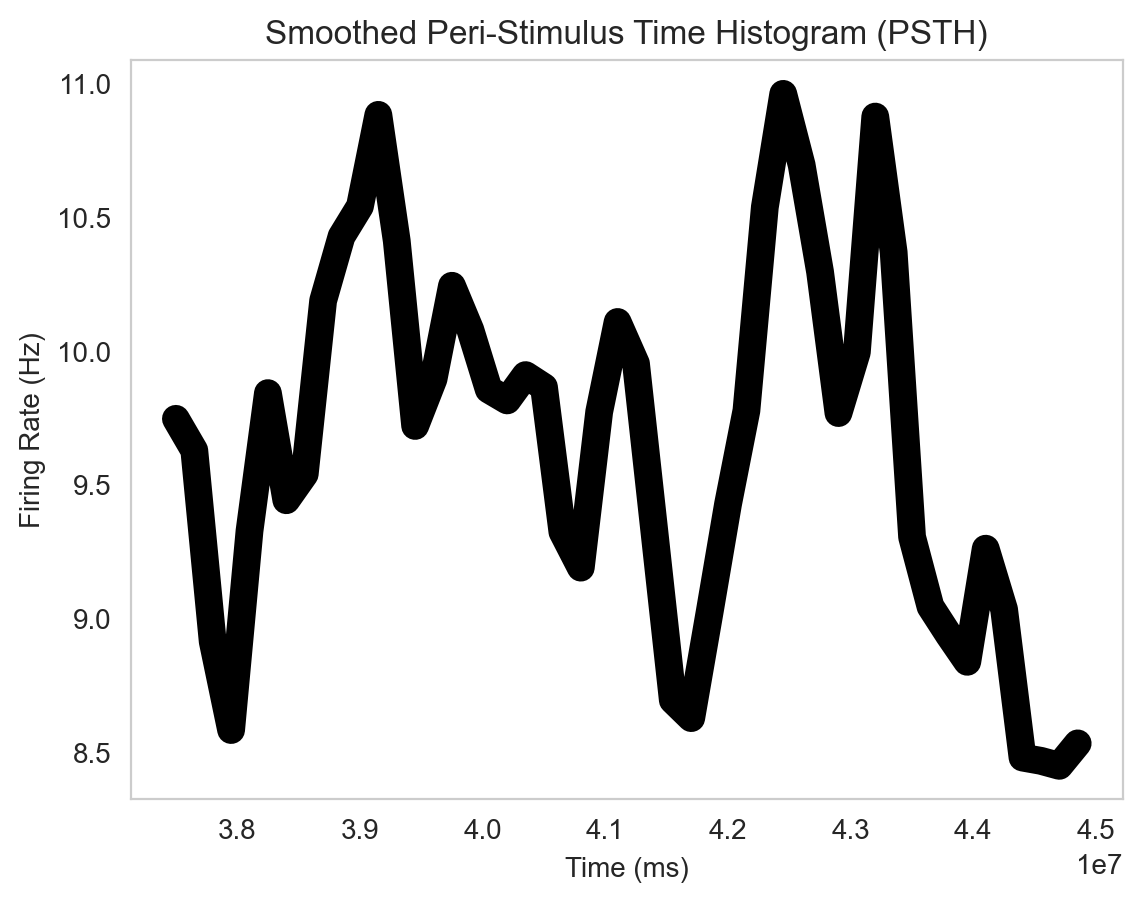

In [13]:
from scipy.ndimage import gaussian_filter1d

# Apply a Gaussian filter for smoothing
psth_rate_smoothed = gaussian_filter1d(psth_rate, sigma=1)

# Plot the smoothed PSTH

plt.plot(psth_time[250:300], psth_rate_smoothed[250:300], color='black', linewidth=10)
plt.title('Smoothed Peri-Stimulus Time Histogram (PSTH)')
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')

plt.show()

### Part 2: Toy parameterization example - pvc6 

In [14]:
# open and load the data

fs = 200000 # sampling rate
one_ms = int(fs / 1000)

total_sweeps = 66

filename = '/Users/blancamartin/Downloads/153098.04.02_data.h5' # filename

# open file
f = h5py.File(filename, 'r')



In [15]:
# helper functions

# load sweeps
def load_sweep(sweep_number):
    # load sweep
    dset = f['Sweep_' + str(sweep_number)]

    # create array of time indices
    convert_to_ms = (fs / 1000)
    times = np.arange(0, np.shape(dset)[0]) / convert_to_ms # in ms instead of sec

    return dset, times



# find the spike times
def find_spike_times(data, thresh_mv, thresh_ms):
    # thresh_mv is the voltage threshold that needs to be crossed
    # thresh_ms is how many ms each peak needs to be from the next

    peaks = find_peaks(data, height=thresh_mv, distance=thresh_ms)
    idx_spikes = peaks[0] # spike indices
    amp_spikes = peaks[1]['peak_heights'] # spike amplitudes

    return idx_spikes, amp_spikes



In [16]:
dset, times = load_sweep(14)

stim = dset[:, 0]
data = dset[:, 1]

thresh_mv = -10
thresh_ms = one_ms * 1

idx_spikes, amp_spikes = find_spike_times(data, thresh_mv, thresh_ms)

i_spikes = 1

window_length = (10, 10)
window_pre  = int(one_ms * window_length[0])
window_post = int(one_ms * window_length[1])

window_spike_pre  = idx_spikes[i_spikes] - window_pre
window_spike_post = idx_spikes[2] + window_post

windowed_times = times[window_spike_pre:window_spike_post]
windowed_data  = data[window_spike_pre:window_spike_post]

toy_data  = windowed_data
toy_times = windowed_times

In [17]:
#recreate parameterization using the Spike class
#Run spikeparam on real EAPs 
sp_toy = Spike(thresh_amp=-10, window_length=(10, 10), smooth_frac=.01, )




sp_toy.fit(toy_data, fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/2 [00:00<?, ?it/s]

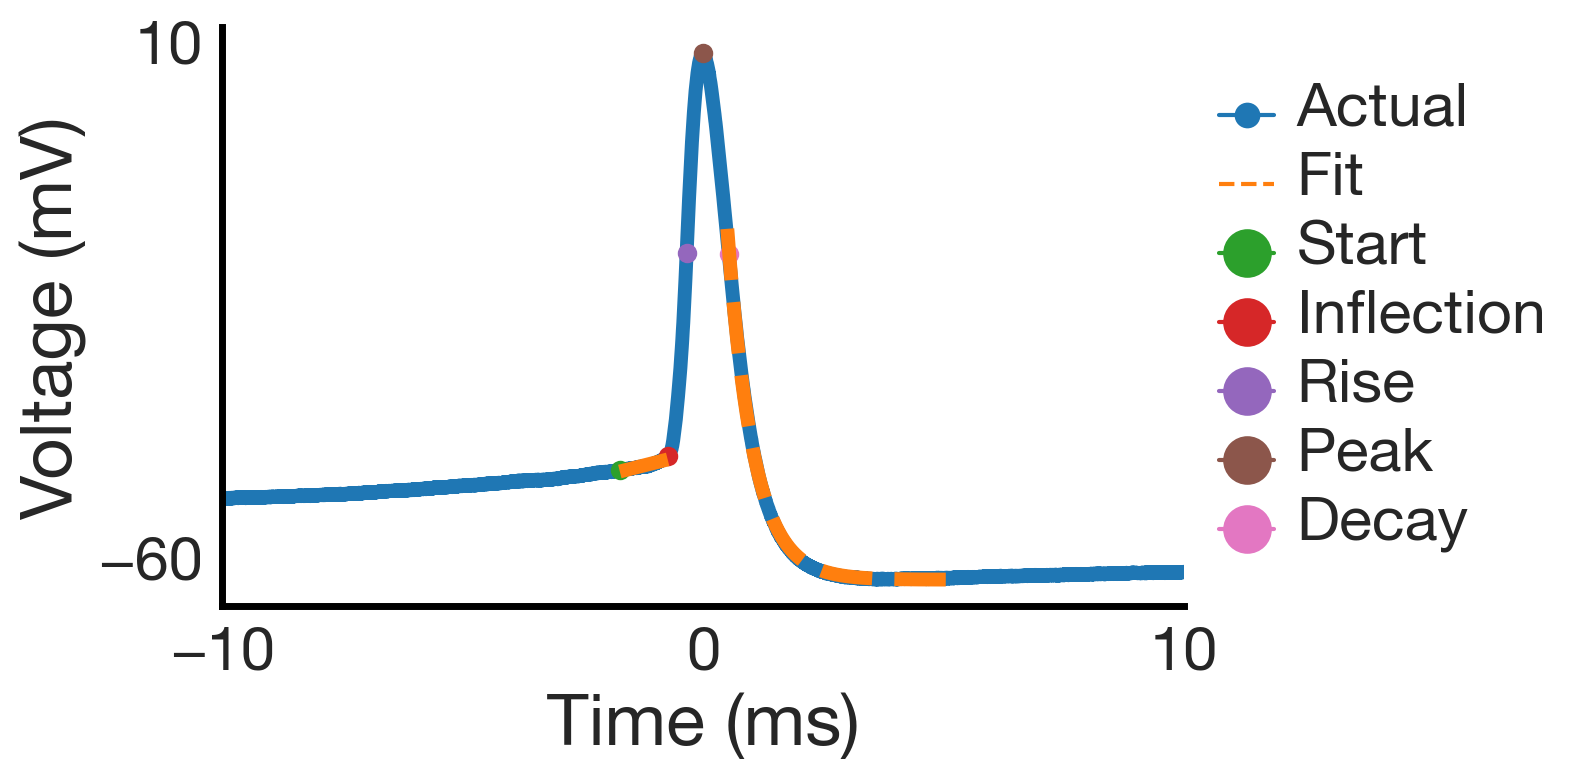

In [18]:
sp_toy.plot(show_points=True, inds=0)
if figure_style:
    apply_figure_style(plt.gca(), xticks=[-10, 0, 10], yticks=[-60, 10],
                       legend_fontsize=22, linewidth=5, point_size=12)
plt.tight_layout()
plt.show()

### Part 3: spikeparam applied to dataset + correlation - spe1 

In [19]:
#threshold in mVs
sp = Spike(thresh_amp=100, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt_c14, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp.fit(patch_filt_c14, patch_fs_c14, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/7598 [00:00<?, ?it/s]

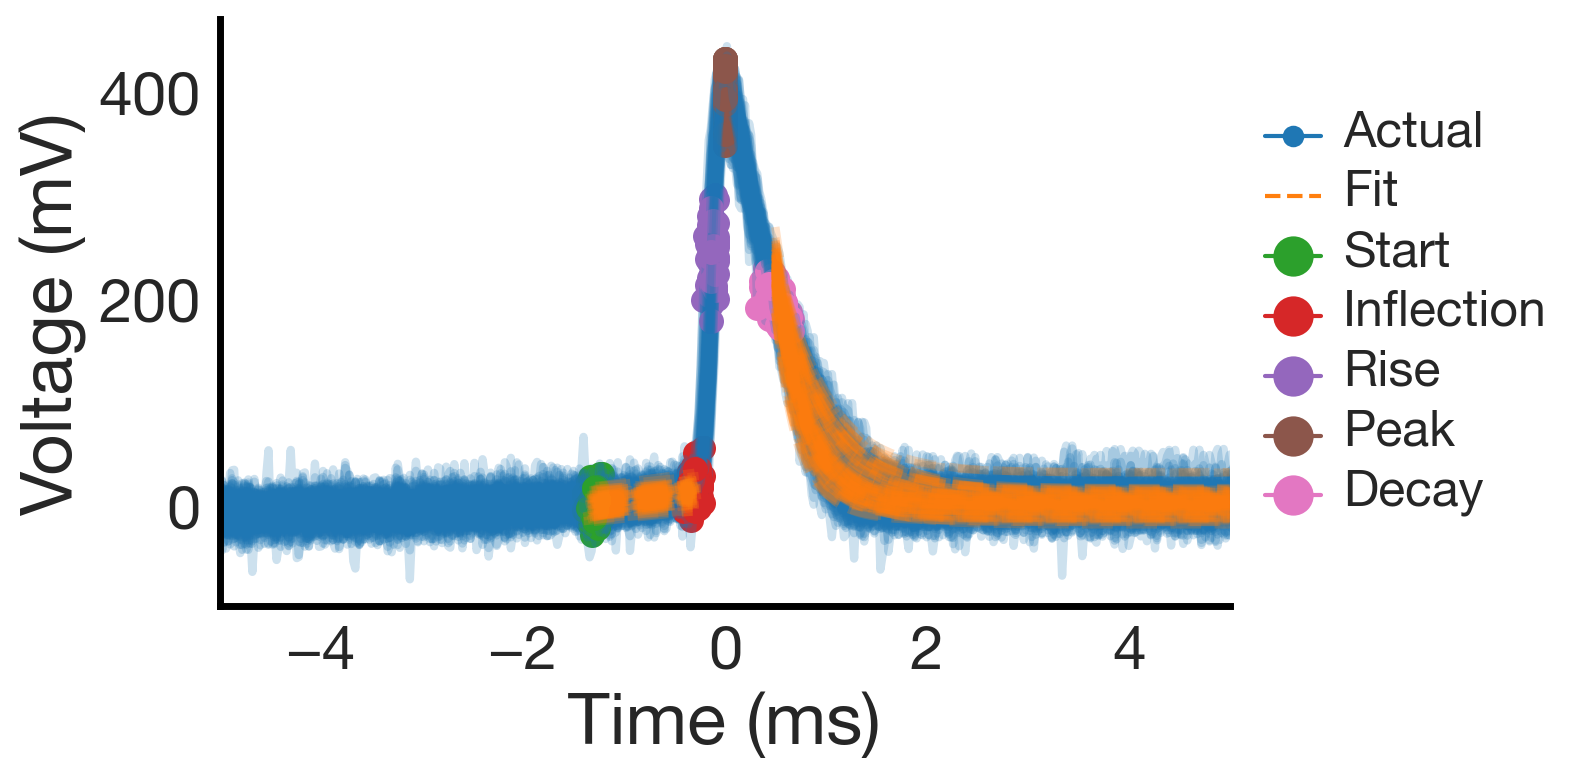

In [20]:
sp.plot(inds=np.arange(100), mode='full', show_points=True)
if figure_style:
    apply_figure_style(plt.gca())
plt.tight_layout()
plt.show()

In [21]:
"""sp.plot(mode='full', show_points=True)
if figure_style:
    apply_figure_style(plt.gca())
plt.tight_layout()
plt.show()"""

"sp.plot(mode='full', show_points=True)\nif figure_style:\n    apply_figure_style(plt.gca())\nplt.tight_layout()\nplt.show()"

In [22]:
df_features = sp.df_features
# Add an index column to df_features to maintain original indices
df_features['original_index'] = df_features.index

In [23]:
from spikeparam_plotting import display_feature_table  # fresh import each run
display_feature_table(df_features, nrows=2, save_path='feature_table.png')


spike id,rampamp,inflectiontime,inflectionamp,peakamp,peakwidth,peaksharpness,explambda,expconst,logisi,r2 rampfit,r2 decayfit
0,10.96,0.30,18.38,395.95,0.62,79.82,3.95,-7.97,1.03,0.11,0.93
1,1.00,0.34,6.73,367.47,0.76,49.17,2.08,16.16,1.97,0.00,0.95


Saved to feature_table.png


In [24]:
# Ensure inflection times are between 0 and 2 ms
df_features  = df_features .loc[df_features['inflection_time'] > 0.]
df_features = df_features .loc[df_features['inflection_time'] < 2.]
# Remove low r-squares (ramping fits are especially noisy)
df_features = df_features.loc[df_features['r_squared_exp']  >= .5]
df_features = df_features.loc[df_features['r_squared_ramp'] >= .1]
# log10 ISIs
df_features[['isi']] = np.log10(df_features[['isi']])
df_features.rename(columns={'isi':'log_isi'}, inplace=True)
# drop no-longer-used QC features
df_features = df_features.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_features = df_features.replace([np.inf, -np.inf], np.nan)



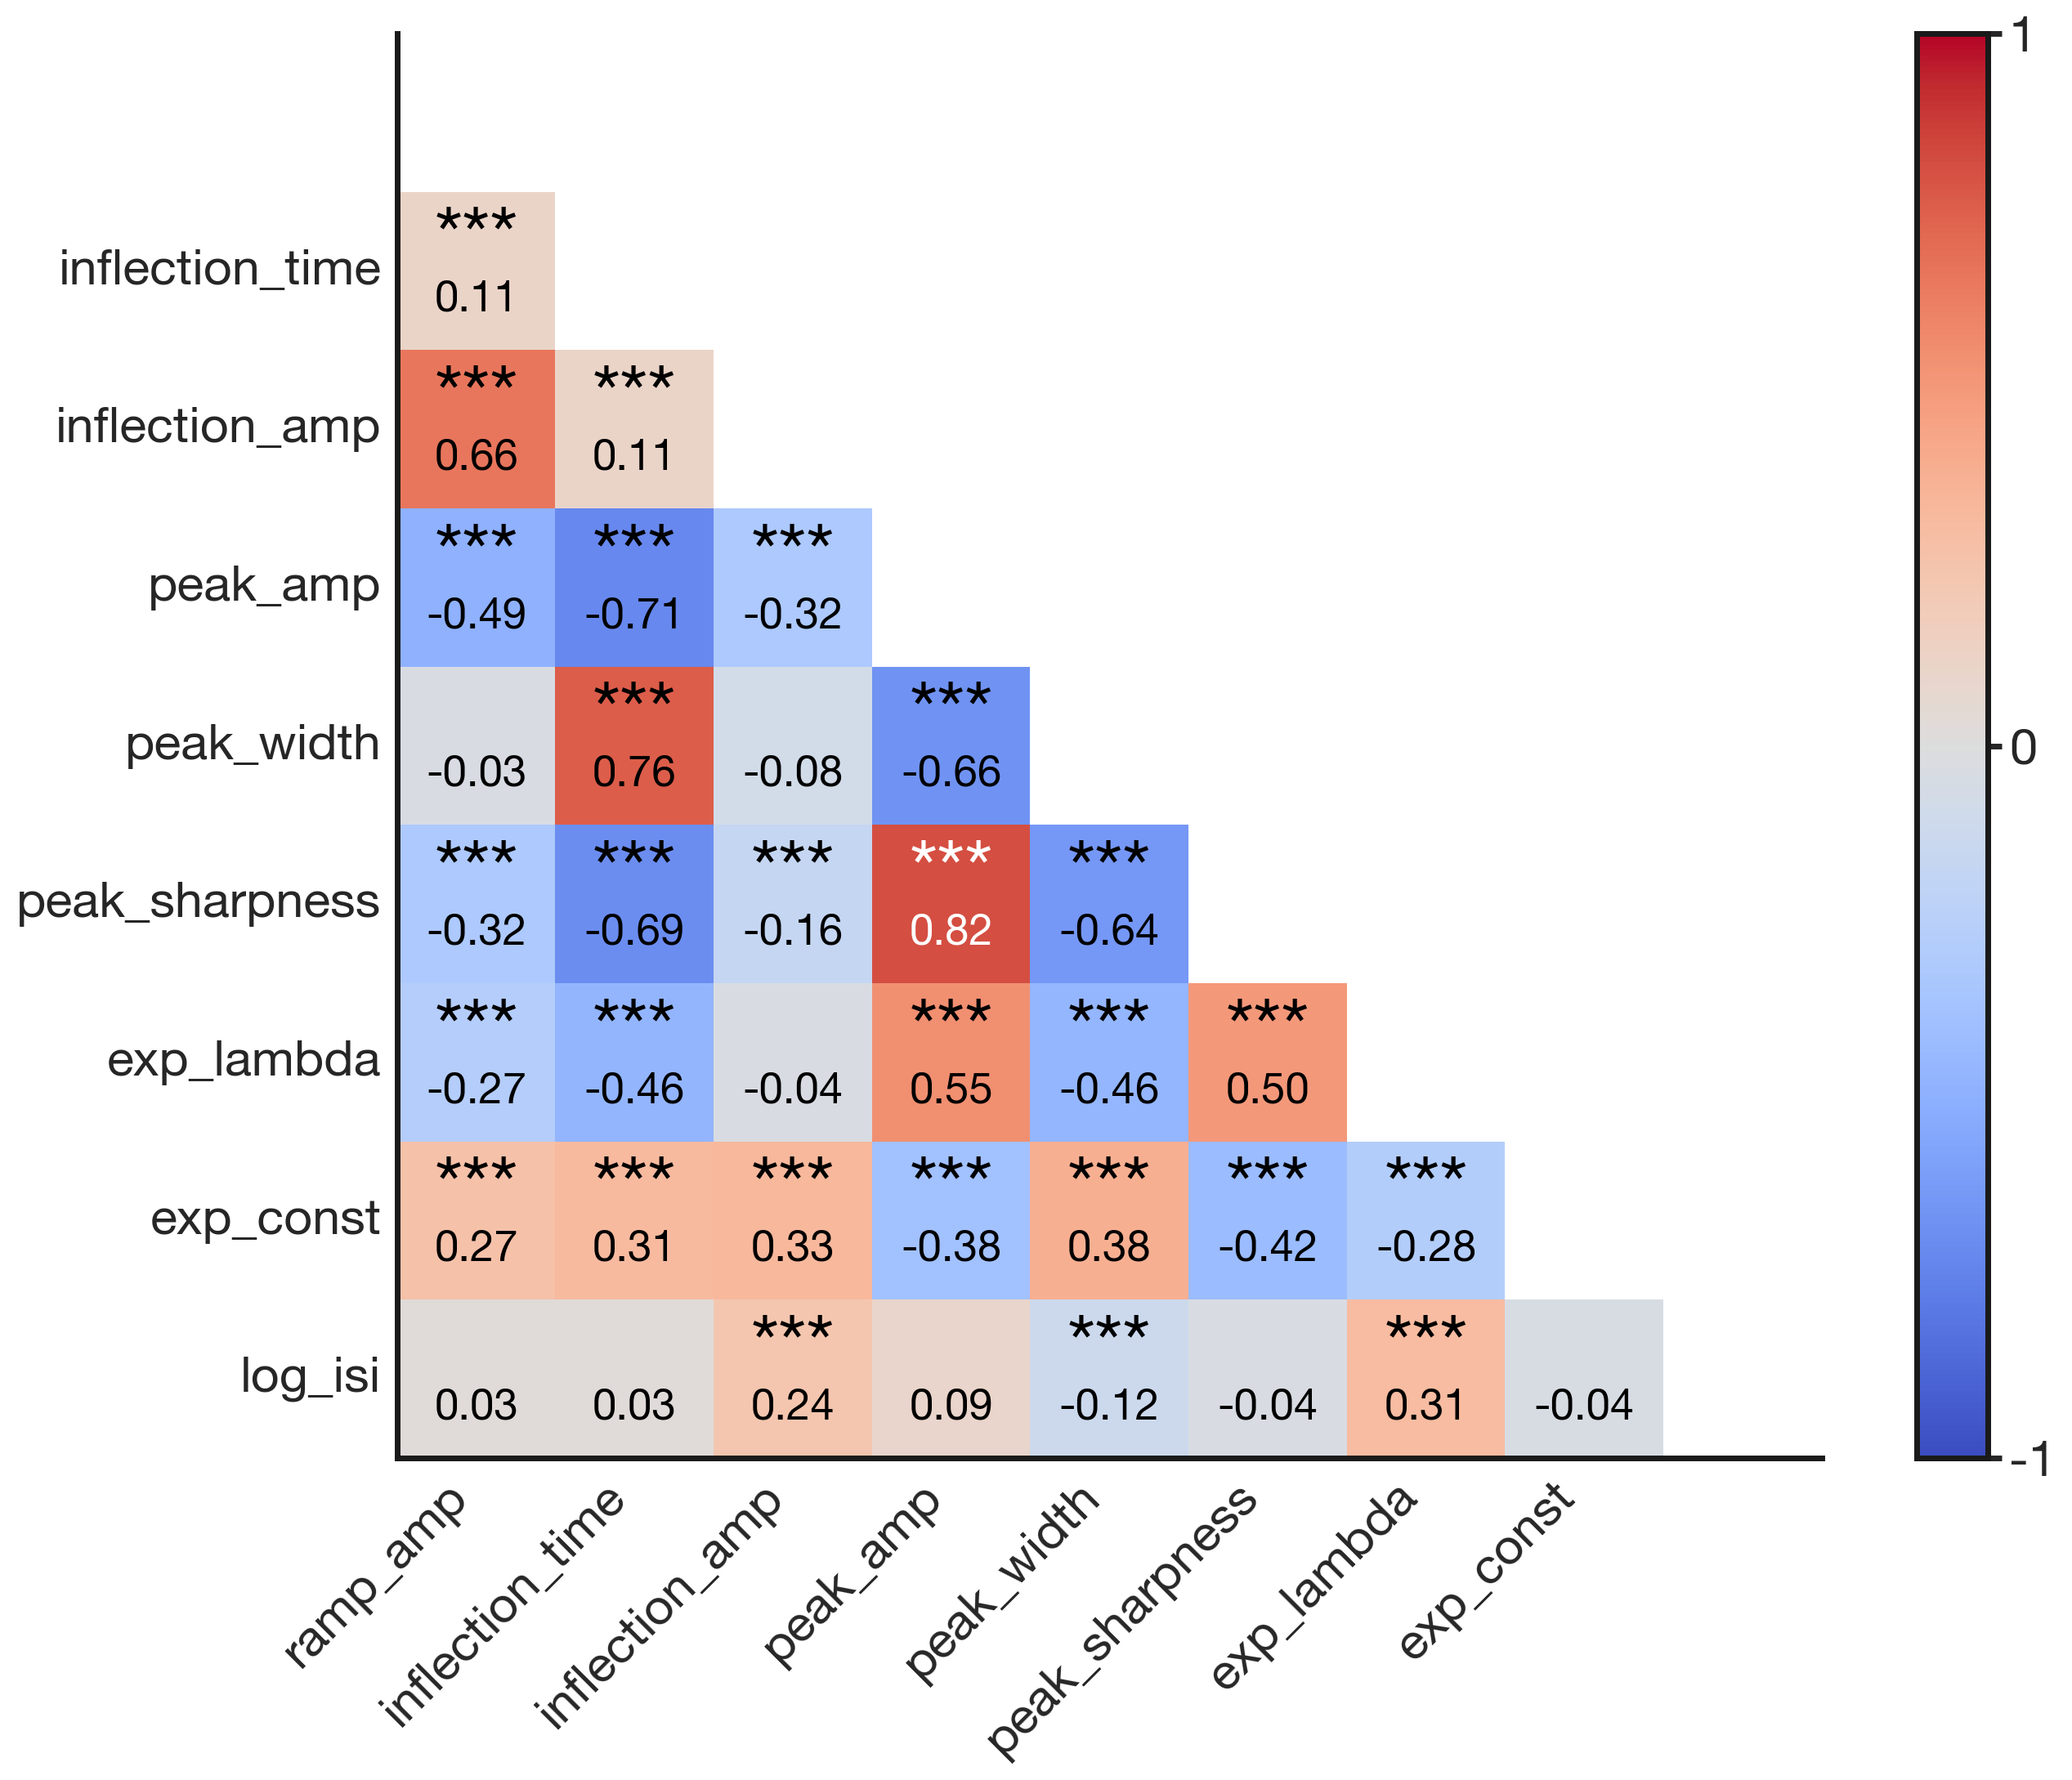

In [25]:
spike_features = [c for c in df_features.columns if c != 'original_index']
plot_corr_heatmap_only_spk(df_features, spike_features)